ModuleNotFoundError: No module named 'src'

In [2]:
import os
import sys

# Move up one level to the project root directory and add it to the Python path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_insurance_data
from src.eda_utils import generate_descriptive_summary

In [4]:
DATA_PATH = "../data/insurance_data.csv"
df = load_insurance_data(DATA_PATH)

2026-06-17 11:53:24,666 - INFO - Initiating structural data ingestion from: ../data/insurance_data.csv
2026-06-17 11:53:24,723 - INFO - Calculating derived insurance portfolio risk metrics...
2026-06-17 11:53:24,900 - INFO - Ingestion successful. Row count: 10000, Feature columns: 23


In [5]:
print("--- DATA TYPES AND SHAPE SUMMARY ---")
print(df.info())

--- DATA TYPES AND SHAPE SUMMARY ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  object 
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  object 
 3   Province             10000 non-null  object 
 4   VehicleType          10000 non-null  object 
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  

In [6]:
print("\n--- MISSING VALUE PROFILE ---")
missing_matrix = df.isnull().sum()
print(missing_matrix[missing_matrix > 0])


--- MISSING VALUE PROFILE ---
Series([], dtype: int64)


In [8]:
overall_loss_ratio = df['TotalClaims'].sum() / df['TotalPremium'].sum()
print(f"\n🚀 System-Wide Portfolio Loss Ratio: {overall_loss_ratio:.4f}")

# Grouped Loss Ratio Distributions
for dimension in ['Province', 'VehicleType', 'Gender']:
    print(f"\n--- Loss Ratio Breakdown by {dimension} ---")
    grouped = df.groupby(dimension).agg({'TotalPremium': 'sum', 'TotalClaims': 'sum'})
    grouped['Loss_Ratio'] = grouped['TotalClaims'] / grouped['TotalPremium']
    print(grouped.sort_values(by='Loss_Ratio', ascending=False))


🚀 System-Wide Portfolio Loss Ratio: 0.5282

--- Loss Ratio Breakdown by Province ---
             TotalPremium  TotalClaims  Loss_Ratio
Province                                          
Somali            2984984    1826593.0    0.611927
Oromia            6069663    3261061.0    0.537272
Tigray            1990692    1047136.0    0.526016
Addis Ababa       8907374    4653210.0    0.522400
Amhara            4928566    2353885.0    0.477600

--- Loss Ratio Breakdown by VehicleType ---
             TotalPremium  TotalClaims  Loss_Ratio
VehicleType                                       
Luxury            4236839    3569207.0    0.842422
SUV               7256436    4090665.0    0.563729
Hatchback         4532134    1904235.0    0.420163
Sedan             8855870    3577778.0    0.404001

--- Loss Ratio Breakdown by Gender ---
        TotalPremium  TotalClaims  Loss_Ratio
Gender                                       
Female      12791141    6763030.0    0.528728
Male        12090138    6378

C:\Users\Msara\AppData\Local\Temp\ipykernel_14036\1444794905.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=prov_stats, x='Province', y='Loss_Ratio', palette='coolwarm')


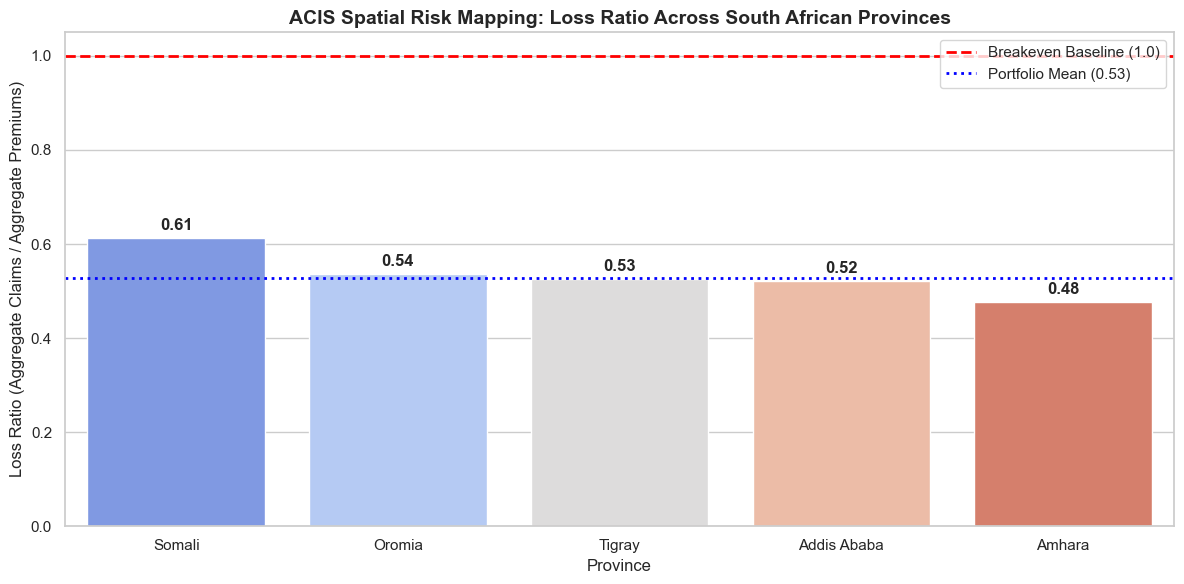

In [9]:
# Cell 2: Plot 1 - Spatial Loss Ratio Analysis
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

prov_stats = df.groupby('Province').agg({'TotalPremium': 'sum', 'TotalClaims': 'sum'}).reset_index()
prov_stats['Loss_Ratio'] = prov_stats['TotalClaims'] / prov_stats['TotalPremium']
prov_stats = prov_stats.sort_values(by='Loss_Ratio', ascending=False)

ax = sns.barplot(data=prov_stats, x='Province', y='Loss_Ratio', palette='coolwarm')
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Breakeven Baseline (1.0)')
plt.axhline(y=overall_loss_ratio, color='blue', linestyle=':', linewidth=2, label=f'Portfolio Mean ({overall_loss_ratio:.2f})')

# Annotate values on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.title('ACIS Spatial Risk Mapping: Loss Ratio Across South African Provinces', fontsize=14, fontweight='bold')
plt.ylabel('Loss Ratio (Aggregate Claims / Aggregate Premiums)', fontsize=12)
plt.xlabel('Province', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../reports/spatial_loss_ratios.png', dpi=300)
plt.show()

In [11]:
# Cell 3: Plot 2 - Bivariate & Outlier Analysis
plt.figure(figsize=(10, 6))

# Aggregate by PostalCode to find geographic risk clustering
postal_agg = df.groupby('PostalCode').agg({
    'TotalPremium': 'mean',
    'TotalClaims': 'mean',
    'Margin': 'sum'
}).reset_index()

scatter = plt.scatter(data=postal_agg, x='TotalPremium', y='TotalClaims', 
                      c='Margin', cmap='RdYlGn', s=100, edgecolors='black', alpha=0.8)

plt.colorbar(scatter, label='Net Margin Contribution (Premium - Claims)')
plt.title('Multivariate Risk Clustering: Mean Premium vs Claims Across Postal Codes', fontsize=14, fontweight='bold')
plt.xlabel('Mean Total Premium (Rand)', fontsize=12)
plt.ylabel('Mean Total Claims (Rand)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('../reports/bivariate_postal_clusters.png', dpi=300)
plt.show()

KeyError: 'PostalCode'

<Figure size 1000x600 with 0 Axes>

In [12]:
print(df.columns.tolist())

['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode', 'TransactionDate', 'Loss_Ratio', 'Margin']


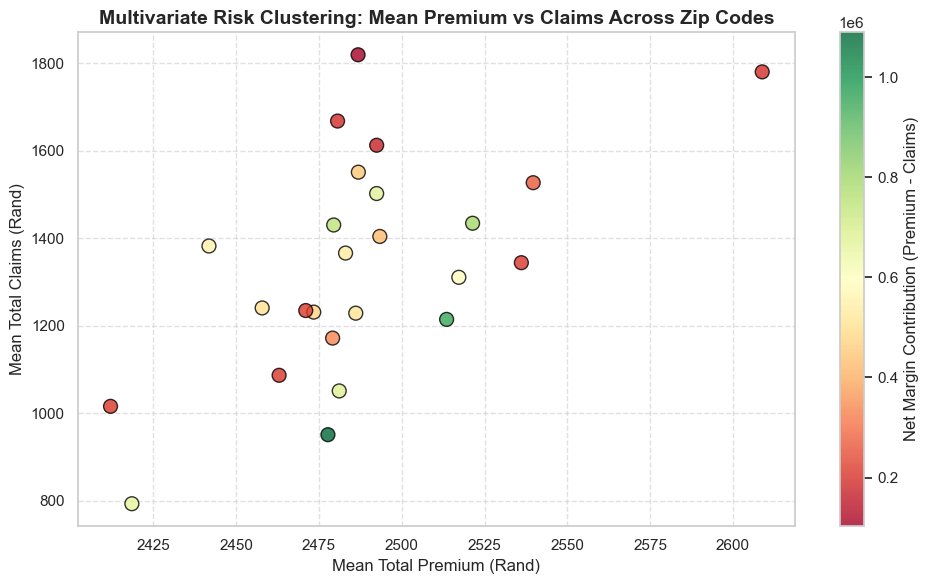

In [13]:
# Cell 3: Plot 2 - Bivariate & Outlier Analysis
plt.figure(figsize=(10, 6))

# Aggregate by ZipCode to find geographic risk clustering
zip_agg = df.groupby('ZipCode').agg({
    'TotalPremium': 'mean',
    'TotalClaims': 'mean',
    'Margin': 'sum'
}).reset_index()

scatter = plt.scatter(data=zip_agg, x='TotalPremium', y='TotalClaims', 
                      c='Margin', cmap='RdYlGn', s=100, edgecolors='black', alpha=0.8)

plt.colorbar(scatter, label='Net Margin Contribution (Premium - Claims)')
plt.title('Multivariate Risk Clustering: Mean Premium vs Claims Across Zip Codes', fontsize=14, fontweight='bold')
plt.xlabel('Mean Total Premium (Rand)', fontsize=12)
plt.ylabel('Mean Total Claims (Rand)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('../reports/bivariate_postal_clusters.png', dpi=300)
plt.show()

C:\Users\Msara\AppData\Local\Temp\ipykernel_14036\1915989356.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_df, x='AutoMake', y='TotalClaims', palette='Set3')


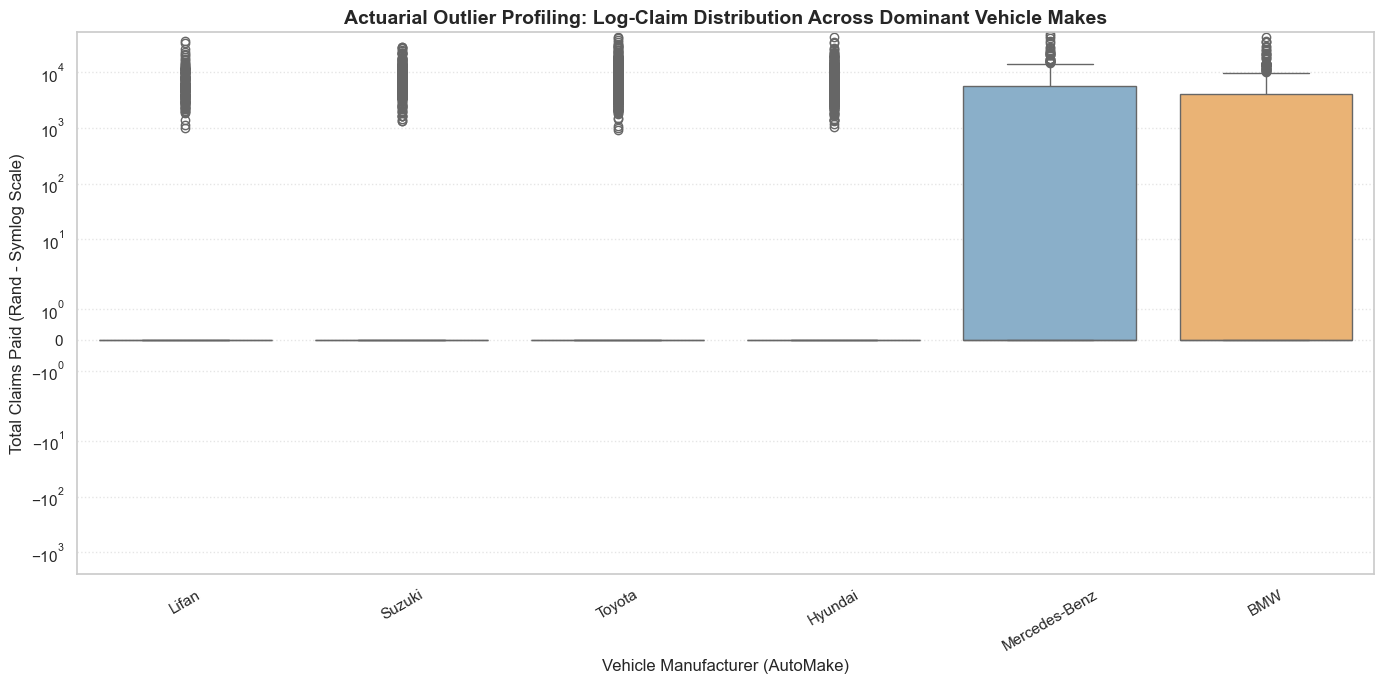

In [14]:

plt.figure(figsize=(14, 7))

# Filter to the top 10 most frequent vehicle manufacturers using AutoMake
top_makes = df['AutoMake'].value_counts().index[:10]
filtered_df = df[df['AutoMake'].isin(top_makes)]

sns.boxplot(data=filtered_df, x='AutoMake', y='TotalClaims', palette='Set3')
plt.yscale('symlog') # Using symbolic log scale to accurately represent heavy right-skewed outlier tails
plt.title('Actuarial Outlier Profiling: Log-Claim Distribution Across Dominant Vehicle Makes', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Manufacturer (AutoMake)', fontsize=12)
plt.ylabel('Total Claims Paid (Rand - Symlog Scale)', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('../reports/vehicle_outliers.png', dpi=300)
plt.show()